# Merge manifold analysis

Quantifies latent-state signatures for the merge operation recorded by `merge_recorder.py`.


## Goals

* detect the emergence of a mixed A/B cluster in C
* track local curvature near the merged unit
* evaluate linear separability between merged and constituent units
* monitor distance relationships among A, B, and the merged unit


In [3]:
from __future__ import annotations

import json
from pathlib import Path
from typing import Dict, List, Optional, Sequence

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.spatial.distance import cdist
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.linalg import svd
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

plt.style.use("seaborn-v0_8")
np.set_printoptions(edgeitems=5, threshold=20)


In [4]:
# Parameters
PROJECT_ROOT = Path.cwd().resolve().parents[1]
RUN_ROOT = PROJECT_ROOT / "runs" / "merge_manifold"
RUN_FILTER: Optional[str] = None
MAX_RUNS: Optional[int] = None
AREA = "C"
CURVATURE_NEIGHBORS = 24
CLASSIFIER_CV = 5
print("Run root:", RUN_ROOT)


Run root: /Users/justincharney/zed/assemblies/runs/merge_manifold


In [6]:
CLASS_COLORS = {
    "a_only": "#1f77b4",
    "b_only": "#d62728",
    "joint": "#9467bd",
    "merge": "#2ca02c",
    "other": "#8c564b",
}
CLASS_LABELS = {
    "a_only": "A drive",
    "b_only": "B drive",
    "joint": "joint seed",
    "merge": "merge recur",
    "other": "other",
}


def classify_stage(label: str) -> str:
    token = label.lower()
    if token.startswith("seed_a") or token.startswith("a_stabilize"):
        return "a_only"
    if token.startswith("seed_b") or token.startswith("b_stabilize"):
        return "b_only"
    if token.startswith("joint"):
        return "joint"
    if token.startswith("merge"):
        return "merge"
    return "other"


In [7]:
def find_run_dirs(root: Path, substring: Optional[str], limit: Optional[int]) -> List[Path]:
    manifest_files = sorted(root.rglob("manifest.json"))
    run_dirs: List[Path] = []
    for manifest in manifest_files:
        run_dir = manifest.parent
        if substring and substring not in str(run_dir):
            continue
        run_dirs.append(run_dir)
        if limit and len(run_dirs) >= limit:
            break
    return run_dirs


def load_trials(run_dirs: Sequence[Path], area: str) -> Dict[str, Dict[str, object]]:
    trials: Dict[str, Dict[str, object]] = {}
    for run_dir in run_dirs:
        config_path = run_dir / "config.json"
        manifest_path = run_dir / "manifest.json"
        if not config_path.exists() or not manifest_path.exists():
            continue
        with config_path.open("r", encoding="utf-8") as handle:
            config = json.load(handle)
        with manifest_path.open("r", encoding="utf-8") as handle:
            manifest = json.load(handle)
        run_label = str(run_dir.relative_to(RUN_ROOT))
        for entry in manifest:
            npz_path = run_dir / entry["record_file"]
            key = f"{run_label}::trial_{entry.get('trial_index', 0):03d}"
            snapshots: List[Dict[str, object]] = []
            with np.load(npz_path, allow_pickle=True) as payload:
                times = payload[f"{area}_times"]
                stages = payload[f"{area}_stages"]
                dense_key = f"{area}_dense"
                if dense_key not in payload.files:
                    raise RuntimeError(f"{npz_path} lacks '{dense_key}'. Rerun merge_recorder with record_dense=True.")
                dense = payload[dense_key]
                for order, (time, stage, vec) in enumerate(zip(times, stages, dense)):
                    stage_name = str(stage)
                    snapshots.append(
                        {
                            "order": order,
                            "time": int(time),
                            "stage": stage_name,
                            "stage_class": classify_stage(stage_name),
                            "dense": np.asarray(vec, dtype=float),
                        }
                    )
            trials[key] = {
                "key": key,
                "run_path": run_dir,
                "run_label": run_label,
                "snapshots": snapshots,
                "config": config,
                "metrics": {k: v for k, v in entry.items() if k not in ("record_file", "trial_index")},
            }
    return trials


In [8]:
run_dirs = find_run_dirs(RUN_ROOT, RUN_FILTER, MAX_RUNS)
print(f"Found {len(run_dirs)} run directories")
trials = load_trials(run_dirs, AREA)
print(f"Loaded {len(trials)} trials")


Found 9 run directories
Loaded 9 trials


### Helper utilities

In [9]:
def stack_by_class(trial: Dict[str, object], stage_class: str):
    snapshots = trial["snapshots"]
    rows = [snap["dense"] for snap in snapshots if snap["stage_class"] == stage_class]
    return np.vstack(rows) if rows else np.zeros((0, len(snapshots[0]["dense"])) )


def get_merge_segments(trial: Dict[str, object]):
    return [snap for snap in trial["snapshots"] if snap["stage_class"] == "merge"]


### Cluster emergence

In [10]:
cluster_profiles: List[Dict[str, object]] = []
for trial in trials.values():
    segments = get_merge_segments(trial)
    if not segments:
        continue
    matrix = np.vstack([seg["dense"] for seg in segments])
    pca = PCA(n_components=min(10, matrix.shape[1], matrix.shape[0])).fit_transform(matrix)
    Z = linkage(pca, method="ward")
    labels = fcluster(Z, t=3, criterion="maxclust")
    cluster_profiles.append({"trial_key": trial["key"], "labels": labels, "segments": segments})
print(f"Clustered {len(cluster_profiles)} trials")


Clustered 9 trials


### Curvature hotspots

In [11]:
def curvature_scores(matrix: np.ndarray, k: int) -> np.ndarray:
    dist = cdist(matrix, matrix, metric="cosine")
    np.fill_diagonal(dist, np.inf)
    neighbor_idx = np.argpartition(dist, kth=min(k, matrix.shape[0]-1), axis=1)[:, :min(k, matrix.shape[0]-1)]
    scores = []
    for i, nbrs in enumerate(neighbor_idx):
        local = matrix[nbrs] - matrix[i]
        if local.size == 0:
            scores.append(np.nan)
            continue
        _, svals, _ = svd(local, full_matrices=False)
        score = np.sum(svals[1:]) / (svals[0] + 1e-8) if svals.size > 1 else 0.0
        scores.append(score)
    return np.asarray(scores)

curvature_records: List[Dict[str, object]] = []
for profile in cluster_profiles:
    matrix = np.vstack([seg["dense"] for seg in profile["segments"]])
    if matrix.shape[0] <= CURVATURE_NEIGHBORS:
        continue
    scores = curvature_scores(matrix, CURVATURE_NEIGHBORS)
    for seg, score in zip(profile["segments"], scores):
        curvature_records.append({"trial_key": profile["trial_key"], "stage": seg["stage"], "score": score})
print(f"Curvature observations: {len(curvature_records)}")


Curvature observations: 360


### Linear separability

In [12]:
def separability_score(trial: Dict[str, object]) -> Optional[float]:
    a_mat = stack_by_class(trial, "a_only")
    b_mat = stack_by_class(trial, "b_only")
    m_mat = stack_by_class(trial, "merge")
    if min(a_mat.shape[0], b_mat.shape[0], m_mat.shape[0]) < 3:
        return None
    X = np.vstack([a_mat, b_mat, m_mat])
    y = np.concatenate([
        np.zeros(a_mat.shape[0], dtype=int),
        np.ones(b_mat.shape[0], dtype=int),
        np.full(m_mat.shape[0], 2, dtype=int),
    ])
    scaler = StandardScaler(with_mean=False)
    Xn = scaler.fit_transform(X)
    clf = LogisticRegression(max_iter=1000)
    scores = cross_val_score(clf, Xn, y, cv=min(CLASSIFIER_CV, np.unique(y, return_counts=True)[1].min()))
    return scores.mean()

separability_records: List[float] = []
for trial in trials.values():
    score = separability_score(trial)
    if score is not None:
        separability_records.append(score)
print(f"Separability samples: {len(separability_records)}")


/Users/justincharney/zed/assemblies/.venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/justincharney/zed/assemblies/.venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/justincharney/zed/assemblies/.venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/justincharney/zed/assemblies/.venv/lib/python3.9

Separability samples: 9


### Distance dynamics

In [13]:
def distance_records_for_trial(trial: Dict[str, object]):
    snaps = trial["snapshots"]
    a_vec = np.mean(stack_by_class(trial, "a_only"), axis=0) if stack_by_class(trial, "a_only").size else None
    b_vec = np.mean(stack_by_class(trial, "b_only"), axis=0) if stack_by_class(trial, "b_only").size else None
    if a_vec is None or b_vec is None:
        return []
    records = []
    for snap in snaps:
        if snap["stage_class"] != "merge":
            continue
        vec = snap["dense"]
        d_a = np.linalg.norm(vec - a_vec)
        d_b = np.linalg.norm(vec - b_vec)
        d_ab = np.linalg.norm(a_vec - b_vec)
        records.append({
            "trial_key": trial["key"],
            "stage": snap["stage"],
            "d_a": d_a,
            "d_b": d_b,
            "d_ab": d_ab,
        })
    return records

distance_records: List[Dict[str, object]] = []
for trial in trials.values():
    distance_records.extend(distance_records_for_trial(trial))
print(f"Distance records: {len(distance_records)}")


Distance records: 360


### Visualizations

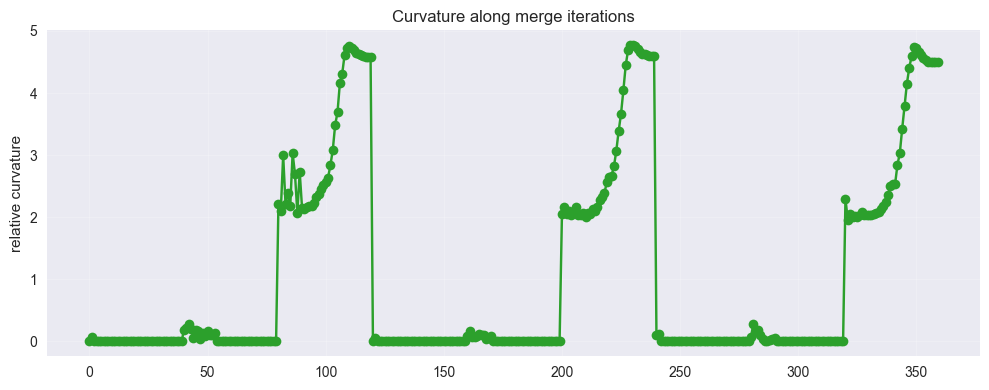

In [14]:
def plot_curvature(records):
    if not records:
        print('No curvature records'); return
    stages = [rec['stage'] for rec in records]
    scores = [rec['score'] for rec in records]
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(scores, '-o', color=CLASS_COLORS['merge'])
    ax.set_title('Curvature along merge iterations')
    ax.set_ylabel('relative curvature')
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
plot_curvature(curvature_records)
